# Tutorial: Análisis de Componentes Principales (PCA) aplicado a clasificación

En este tutorial trabajaremos con el dataset **Breast Cancer Wisconsin**, incluido en scikit-learn, para aprender a utilizar PCA como una etapa de preprocesamiento antes de realizar clasificación. A lo largo del notebook iremos explorando los datos, construyendo un modelo base, aplicando PCA, y comparando resultados, siempre explicando qué estamos haciendo, por qué lo hacemos, y qué nos dicen los resultados.

Al finalizar, habrás aprendido a:
- Usar PCA como paso de preprocesamiento para clasificación.
- Analizar la varianza explicada para decidir cuántos componentes conservar.
- Interpretar las cargas (loadings) de los componentes principales.
- Comparar el rendimiento de modelos con y sin reducción de dimensionalidad.

Comencemos importando las librerías que utilizaremos. Necesitaremos `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para las visualizaciones, y varios módulos de `scikit-learn` que iremos importando conforme los necesitemos.

También agregaremos `warnings.filterwarnings('ignore')` para suprimir las advertencias de deprecación que genera scikit-learn en algunas versiones. Esto no afecta los resultados, solo limpia la salida para que sea más legible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Importar el dataset

El dataset Breast Cancer Wisconsin contiene mediciones de características de núcleos celulares obtenidas a partir de imágenes digitalizadas de biopsias de mama. Cada observación se clasifica como maligna (0) o benigna (1). Ya viene incluido en scikit-learn, así que simplemente lo cargamos con `load_breast_cancer()`.

Usaremos `pd.DataFrame()` para convertir los datos en un DataFrame de pandas. Esto nos facilita la exploración y visualización. Además, crearemos una columna `target_name` que traduce los valores numéricos (0 y 1) a sus etiquetas correspondientes ("malignant" y "benign") usando `.map()`.

In [2]:
# Cargar dataset directamente de scikit-learn
cancer_data = load_breast_cancer()

# Crear un DataFrame con los nombres de las columnas originales
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 2. Revisar características

Antes de hacer cualquier cosa con los datos, necesitamos conocerlos. Revisaremos cuatro aspectos clave:
- **Tamaño:** ¿Cuántas observaciones y variables tenemos? Esto lo obtenemos con `.shape`.
- **Tipo de información:** ¿Son numéricas, categóricas? Lo revisamos con `.dtypes.value_counts()`.
- **Distribución de clases:** ¿Está balanceado el dataset? Lo vemos con `.value_counts()` sobre la variable objetivo.
- **Valores faltantes:** ¿Hay huecos que debamos tratar? Lo verificamos con `.isnull().sum().sum()`.

In [3]:
print(f"Tamaño del dataset (filas, columnas): {df.shape}\n")

print("Tipos de información (data types):\n")
print(df.dtypes.value_counts(), "\n")

print("Distribución de las clases:\n")
print(df['target_name'].value_counts(), "\n")

print("Valores nulos (huecos) en el dataset:\n")
print(df.isnull().sum().sum())

Tamaño del dataset (filas, columnas): (569, 32)

Tipos de información (data types):

float64    30
int64       1
str         1
Name: count, dtype: int64 

Distribución de las clases:

target_name
benign       357
malignant    212
Name: count, dtype: int64 

Valores nulos (huecos) en el dataset:

0


El dataset cuenta con 569 observaciones y 30 variables predictoras, todas de tipo numérico (float64). La distribución de clases muestra una ligera mayoría de casos benignos sobre malignos, pero no se trata de un desbalance extremo. Tampoco se encontraron valores nulos, lo cual nos simplifica bastante el preprocesamiento.

## 3. Capacidad de clasificación univariable (gráficas de densidad)

Ahora revisaremos si algunas de las variables originales, por sí solas, son capaces de distinguir entre las dos clases. Para esto usaremos gráficas de densidad (KDE) generadas con `sns.kdeplot()`: si las curvas de cada clase están bien separadas, esa variable tiene buen poder discriminante.

Nuestro dataset tiene 30 predictores, por lo que graficar todos saturaría la visualización. Aquí tomaremos las **primeras 6 variables** del dataset (las que corresponden a las medias de las primeras mediciones: `mean radius`, `mean texture`, `mean perimeter`, `mean area`, `mean smoothness` y `mean compactness`). No las estamos seleccionando de forma aleatoria ni por algún criterio de rendimiento, sino simplemente por orden para tener una muestra representativa del tipo de datos con los que trabajamos.

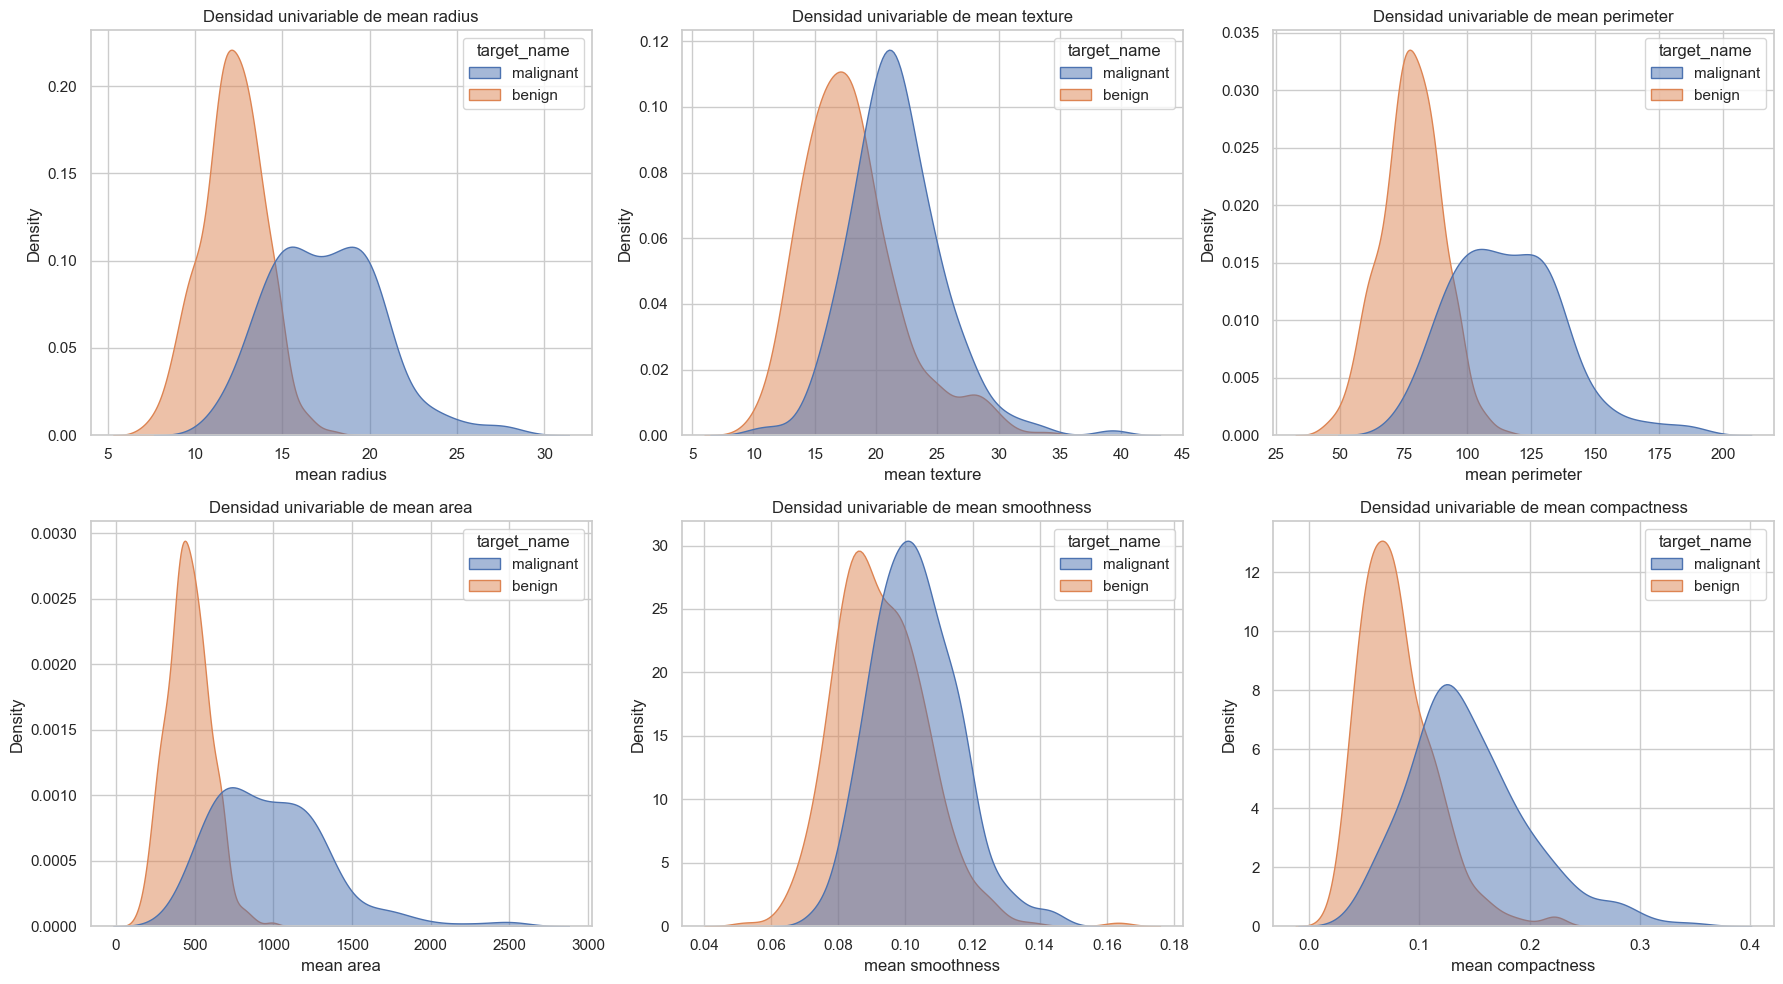

In [4]:
# Tomamos las primeras 6 variables del dataset (por orden, no por selección aleatoria)
# Son: mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness
features_to_plot = list(cancer_data.feature_names[:6])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # sns.kdeplot genera curvas de densidad; hue separa por clase, fill rellena las curvas
    sns.kdeplot(data=df, x=feature, hue="target_name", fill=True, common_norm=False, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Densidad univariable de {feature}")

plt.tight_layout()
plt.show()

En las gráficas podemos ver que variables como `mean radius`, `mean perimeter` y `mean area` muestran distribuciones claramente distintas entre tumores malignos y benignos, lo que sugiere buen poder de separación univariable. Otras, como `mean smoothness`, tienen distribuciones más superpuestas, indicando menor capacidad discriminante por sí solas. Esto no significa que no sean útiles; combinadas con otras variables podrían aportar información adicional.

## 4. Capacidad de clasificación bivariable (gráficas de dispersión)

Pasemos a analizar combinaciones de pares de variables. Un pairplot (generado con `sns.pairplot()`) nos permite ver si al combinar dos variables logramos una mejor separación entre las clases. Si los puntos de distinto color forman nubes o grupos distintos, es señal de que un clasificador podría trazar una frontera de decisión efectiva en ese subespacio.

Al igual que antes, no utilizaremos las 30 variables (el pairplot sería enorme e ilegible). Tomaremos las **primeras 4 variables** (`mean radius`, `mean texture`, `mean perimeter`, `mean area`), de nuevo por orden, solo para tener una visualización manejable. La diagonal del pairplot muestra la distribución de cada variable individual (tipo KDE), mientras que las celdas fuera de la diagonal muestran gráficas de dispersión entre cada par.

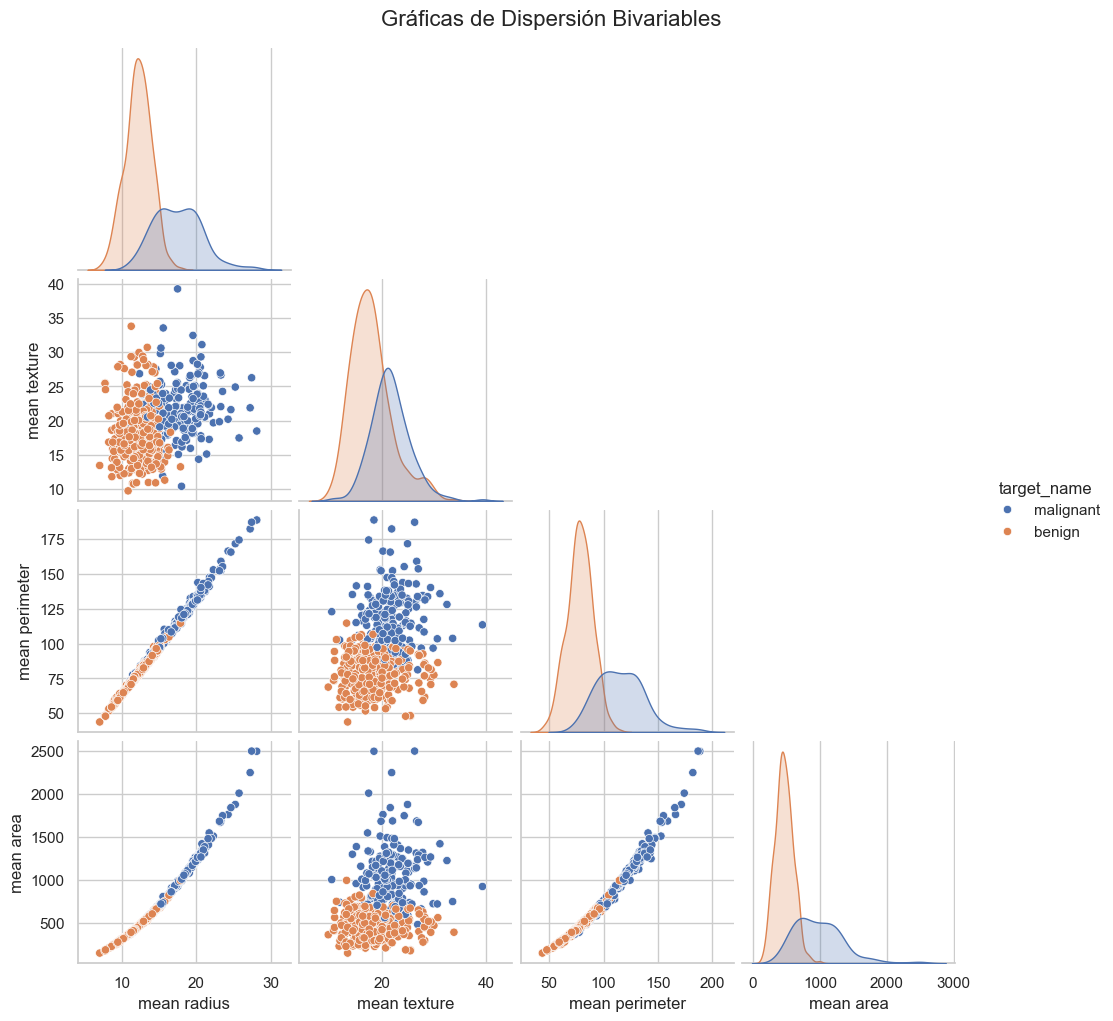

In [5]:
# Tomamos las primeras 4 variables para el pairplot (por orden, para mantener la visualización legible)
features_bivariables = list(cancer_data.feature_names[:4])

# sns.pairplot genera una matriz de gráficas de dispersión entre todos los pares
# diag_kind="kde" muestra distribuciones de densidad en la diagonal
# corner=True muestra solo la mitad inferior (la superior sería un espejo)
sns.pairplot(df, vars=features_bivariables, hue="target_name", diag_kind="kde", corner=True)
plt.suptitle("Gráficas de Dispersión Bivariables", y=1.02, fontsize=16)
plt.show()

Se puede apreciar que ciertas combinaciones de variables generan una separación más clara entre las dos clases. Por ejemplo, `mean radius` contra `mean perimeter` o `mean area` muestran grupos bastante distinguibles. Esto tiene sentido, pues son variables que miden aspectos relacionados del tamaño celular, y los tumores malignos tienden a ser más grandes que los benignos.

## 5. Separación de datos (Train y Test)

Es momento de preparar los datos para el modelado. Dividiremos el dataset en 70% para entrenamiento y 30% para prueba usando `train_test_split()` de scikit-learn.

Usamos el parámetro `stratify=y` para asegurar que la proporción de clases (maligno/benigno) se mantenga en ambos conjuntos. El `random_state=42` fija la semilla aleatoria para que los resultados sean reproducibles.

Es importante hacer esta separación **antes** de estandarizar. Si estandarizamos primero, la información del conjunto de prueba "contaminaría" los parámetros del escalador, generando lo que se conoce como fuga de datos (data leakage). El conjunto de prueba debe simular datos que el modelo nunca ha visto.

In [6]:
from sklearn.model_selection import train_test_split

# Separamos predictores (X) de la variable objetivo (y)
X = df.drop(columns=['target', 'target_name'])
y = df['target']

# Dividir 70% train y 30% test
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (398, 30)
Tamaño de X_test: (171, 30)


## 6. Estandarización de datos

PCA es sensible a la escala de las variables. Si una variable tiene valores en miles y otra en decimales, la primera dominará los componentes principales simplemente por su magnitud, no por su importancia real. Por eso estandarizamos los datos.

Usaremos `StandardScaler()` de scikit-learn, que por defecto transforma los datos para que tengan **media 0** y **desviación estándar 1**. Internamente, para cada variable calcula $(x - \mu) / \sigma$, donde $\mu$ es la media y $\sigma$ la desviación estándar.

El scaler se ajusta únicamente con los datos de entrenamiento (`fit_transform`): aprende la media y desviación estándar de cada variable solo del train. Luego aplicamos esa misma transformación a los datos de prueba (`transform`), usando los parámetros aprendidos del train. Esto evita la fuga de datos.

In [7]:
from sklearn.preprocessing import StandardScaler

# StandardScaler() por defecto estandariza a media=0 y desviación estándar=1
# Internamente calcula: (x - media) / desv_estandar para cada variable
scaler = StandardScaler()

# fit_transform: aprende media y std del train, y transforma el train
X_train_scaled = scaler.fit_transform(X_train)
# transform: usa la media y std aprendidas del train para transformar el test
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para visualizar mejor
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verificamos que la estandarización se aplicó correctamente
print("Media de X_train_scaled (debe ser muy cercana a 0):")
print(np.round(X_train_scaled_df.mean().head(), 4), "\n")

print("Desviación estándar de X_train_scaled (debe ser 1):")
print(np.round(X_train_scaled_df.std().head(), 4))

Media de X_train_scaled (debe ser muy cercana a 0):
mean radius       -0.0
mean texture       0.0
mean perimeter    -0.0
mean area          0.0
mean smoothness    0.0
dtype: float64 

Desviación estándar de X_train_scaled (debe ser 1):
mean radius        1.0013
mean texture       1.0013
mean perimeter     1.0013
mean area          1.0013
mean smoothness    1.0013
dtype: float64


Las desviaciones estándar son prácticamente 1 y las medias son 0, confirmando que la estandarización se aplicó correctamente. Ahora todas las variables tienen la misma escala y contribuirán de forma equitativa cuando apliquemos PCA.

## 7. Modelo de Regresión Logística (optimizando F1-Score)

Antes de aplicar PCA, necesitamos un punto de referencia (baseline). Entrenaremos un modelo de Regresión Logística con las 30 variables originales estandarizadas.

Usaremos `GridSearchCV` para buscar automáticamente la mejor combinación de hiperparámetros. Esta función prueba todas las combinaciones posibles del `param_grid` que le definamos, y para cada combinación realiza validación cruzada de 5 folds (`cv=5`). Los hiperparámetros que buscamos son:
- `C`: Parámetro de regularización. Valores pequeños aplican más regularización (modelo más simple), valores grandes aplican menos.
- `penalty`: Tipo de regularización, `l1` (Lasso) o `l2` (Ridge).
- `class_weight`: Si `None`, trata las clases por igual; si `'balanced'`, ajusta los pesos inversamente proporcional a la frecuencia de cada clase.

Optimizamos el **F1-Score** (`scoring='f1'`), que es la media armónica entre precisión y recall. Es una métrica útil cuando las clases no están perfectamente balanceadas, ya que penaliza tanto los falsos positivos como los falsos negativos.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# LogisticRegression con solver='liblinear' soporta tanto penalty='l1' como 'l2'
logreg = LogisticRegression(solver='liblinear', random_state=42)

# Grid de hiperparámetros: todas las combinaciones serán evaluadas
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],       # Fuerza de regularización
    'penalty': ['l1', 'l2'],                      # Tipo de regularización
    'class_weight': [None, 'balanced']             # Manejo de desbalance de clases
}

# GridSearchCV prueba todas las combinaciones y elige la que maximice F1
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='f1',  # Métrica a optimizar
    cv=5,          # 5 folds de validación cruzada
    n_jobs=-1      # Usar todos los núcleos del procesador para acelerar
)

# Entrenamos usando los datos estandarizados
grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros encontrados para maximizar F1:", grid_search.best_params_)

Mejores hiperparámetros encontrados para maximizar F1: {'C': 1, 'class_weight': None, 'penalty': 'l2'}


## 8. Evaluación del modelo

Evaluemos ahora el mejor modelo encontrado sobre el conjunto de prueba (datos que el modelo nunca vio durante el entrenamiento).

Usaremos `.predict()` para obtener las predicciones de clase, y `.predict_proba()` para obtener las probabilidades (necesarias para calcular el AUC). Calculamos tres métricas:
- **Accuracy:** Proporción total de predicciones correctas.
- **F1-Score:** Balance entre precisión y recall.
- **ROC AUC:** Área bajo la curva ROC; mide qué tan bien el modelo distingue entre clases a lo largo de todos los umbrales de decisión.

En el `classification_report()` usamos `target_names` para que el reporte muestre las etiquetas "Maligno" y "Benigno" en lugar de solo 0 y 1.

In [9]:
# Extraemos el mejor modelo encontrado por GridSearchCV
best_logreg = grid_search.best_estimator_

# Predicciones de clase y probabilidades sobre el conjunto de prueba
y_pred = best_logreg.predict(X_test_scaled)
y_pred_proba = best_logreg.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de la clase positiva (benigno)

# Cálculo de métricas
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("--- Resultados en el Conjunto de Prueba (Test) ---")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

# target_names muestra "Maligno/Benigno" en vez de 0/1
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

--- Resultados en el Conjunto de Prueba (Test) ---
Accuracy : 0.9883
F1 Score : 0.9907
ROC AUC  : 0.9981

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        64
     Benigno       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



Estos resultados constituyen nuestro baseline. Las métricas son bastante altas, lo cual es esperable: el dataset Breast Cancer Wisconsin es relativamente limpio y las clases son razonablemente separables con las 30 variables disponibles. No siempre obtendremos métricas tan altas en otros datasets; depende de la complejidad del problema.

La pregunta clave que responderemos con PCA es: ¿podemos obtener un rendimiento similar usando menos variables?

## 9. Análisis de la varianza explicada (método del codo)

Ahora sí entramos al tema central del tutorial. PCA transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables **no correlacionadas** llamadas componentes principales. Estos componentes se ordenan de mayor a menor según la cantidad de varianza que capturan.

Matemáticamente, el primer componente principal es la combinación lineal normalizada $Z_1 = \phi_{11}X_1 + \phi_{21}X_2 + \cdots + \phi_{p1}X_p$ que tiene la mayor varianza. El segundo componente se obtiene de la misma forma, pero con la restricción de ser ortogonal (perpendicular) al primero, y así sucesivamente. PCA se resuelve internamente mediante descomposición en valores singulares (SVD).

Antes de decidir cuántos componentes conservar, ajustamos `PCA()` sin especificar `n_components`, lo cual genera **todos** los componentes posibles (30, uno por variable). Luego revisamos `explained_variance_ratio_` que nos da la proporción de varianza explicada (PVE) por cada componente. La PVE siempre es positiva y la suma de todas las PVEs es 1.

Graficaremos dos cosas: la varianza individual por componente (buscamos el "codo" donde la ganancia empieza a ser mínima) y la varianza acumulada (para ver cuántos componentes necesitamos para alcanzar ciertos umbrales como 60%, 80%, 95%, etc.).

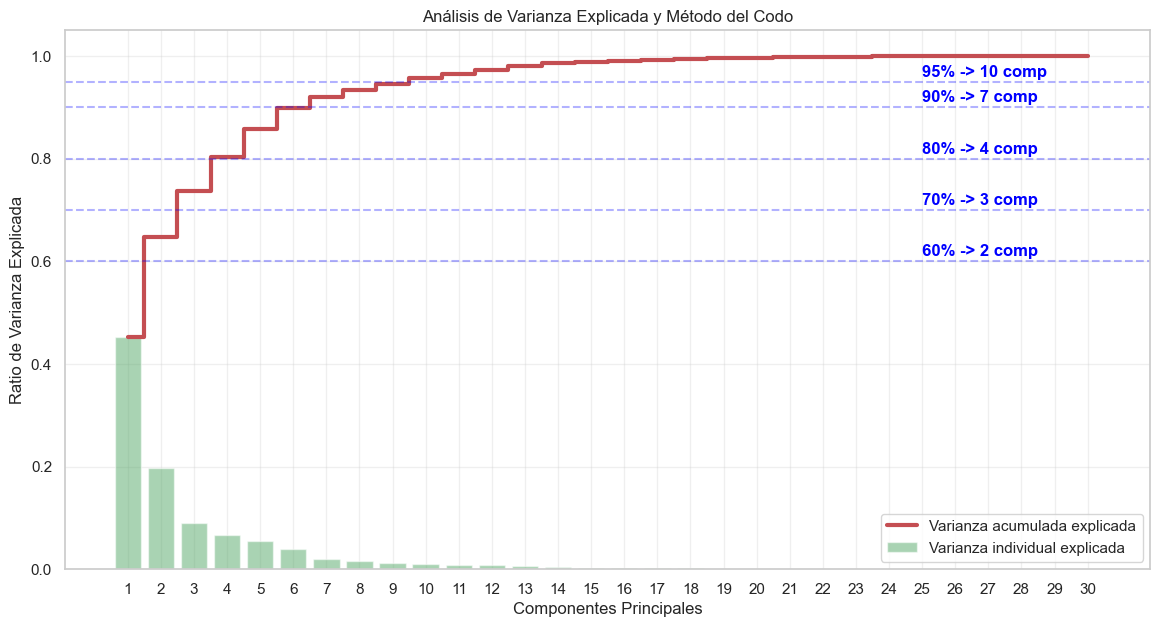

Componentes necesarios para umbrales específicos:
- Para 60% de varianza: 2 componentes
- Para 70% de varianza: 3 componentes
- Para 80% de varianza: 4 componentes
- Para 90% de varianza: 7 componentes
- Para 95% de varianza: 10 componentes


In [10]:
from sklearn.decomposition import PCA

# Ajustamos PCA sin limitar componentes: genera los 30 posibles
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

# explained_variance_ratio_ contiene la PVE de cada componente
exp_var = pca_full.explained_variance_ratio_
# Varianza acumulada: suma progresiva de las PVEs
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(14, 7))

# Barras: varianza individual de cada componente
plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.5, align='center', label='Varianza individual explicada', color='g')

# Línea: varianza acumulada
plt.step(range(1, len(cum_var)+1), cum_var, where='mid', label='Varianza acumulada explicada', color='r', lw=3)

# Líneas horizontales para los umbrales de interés
thresholds = [0.6, 0.7, 0.8, 0.9, 0.95]
for t in thresholds:
    n_comp = np.argmax(cum_var >= t) + 1
    plt.axhline(y=t, color='blue', linestyle='--', alpha=0.3)
    plt.text(len(exp_var)-5, t+0.01, f'{int(t*100)}% -> {n_comp} comp', color='blue', fontweight='bold')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Análisis de Varianza Explicada y Método del Codo')
plt.xticks(range(1, len(cum_var)+1))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Resumen textual
print("Componentes necesarios para umbrales específicos:")
for t in thresholds:
    print(f"- Para {int(t*100)}% de varianza: {np.argmax(cum_var >= t) + 1} componentes")

La gráfica muestra claramente que los primeros componentes concentran la mayor parte de la varianza, mientras que los últimos aportan cantidades cada vez más pequeñas. Esto se debe a que muchas de las 30 variables originales están correlacionadas entre sí (por ejemplo, radio, perímetro y área miden aspectos relacionados del tamaño celular), y PCA captura esa redundancia.

Lo importante aquí es encontrar el "codo" en la gráfica de barras: el punto donde la varianza individual de cada componente deja de disminuir significativamente. También podemos usar la gráfica de varianza acumulada para elegir un umbral específico. Con relativamente pocos componentes ya se alcanza un porcentaje alto de varianza, lo que nos permitirá reducir significativamente la dimensionalidad sin perder demasiada información.

## 10. Transformación PCA final (95% de varianza)

Con base en el análisis anterior, aplicaremos PCA indicando `n_components=0.95`, lo que le dice a scikit-learn que seleccione automáticamente el número mínimo de componentes necesarios para retener al menos el 95% de la varianza explicada.

Como siempre, ajustamos PCA solo con los datos de entrenamiento (`fit_transform`) y luego transformamos ambos conjuntos. También convertimos los resultados a DataFrames con nombres de columna `PC1, PC2, ...` para facilitar la visualización posterior.

In [11]:
from sklearn.decomposition import PCA

# n_components=0.95 selecciona automáticamente los componentes necesarios para retener >= 95% de varianza
pca = PCA(n_components=0.95, random_state=42)

# fit_transform: aprende la transformación del train y la aplica
X_train_pca = pca.fit_transform(X_train_scaled)
# transform: aplica la misma transformación (aprendida del train) al test
X_test_pca = pca.transform(X_test_scaled)

print(f"Variables originales: {X_train_scaled.shape[1]}")
print(f"Componentes principales extraídos (PCA): {pca.n_components_}")
print(f"Varianza total explicada retenida: {np.sum(pca.explained_variance_ratio_):.4f}")

# Convertimos a DataFrames con nombres de columna PC1, PC2, etc.
cols_pca = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
df_train_pca = pd.DataFrame(X_train_pca, columns=cols_pca)
df_train_scaled_heatmap = pd.DataFrame(X_train_scaled, columns=X.columns)

Variables originales: 30
Componentes principales extraídos (PCA): 10
Varianza total explicada retenida: 0.9562


Hemos pasado de 30 variables a un número significativamente menor de componentes principales, conservando al menos el 95% de la varianza total. Eso quiere decir que la gran mayoría de la información sigue presente, pero ahora representada en un espacio más compacto y, como veremos más adelante, completamente decorrelacionado.

## 11. Análisis visual del dataset PCA (univariable y bivariable)

Repetiremos el mismo análisis visual que hicimos en las secciones 3 y 4, pero ahora con los componentes principales en lugar de las variables originales. Esto nos ayudará a ver cómo PCA ha concentrado la capacidad de separación de clases en los primeros componentes.

Primero, las gráficas de densidad para los primeros 3 componentes (PC1, PC2, PC3). Después, un pairplot con los primeros 4 componentes.

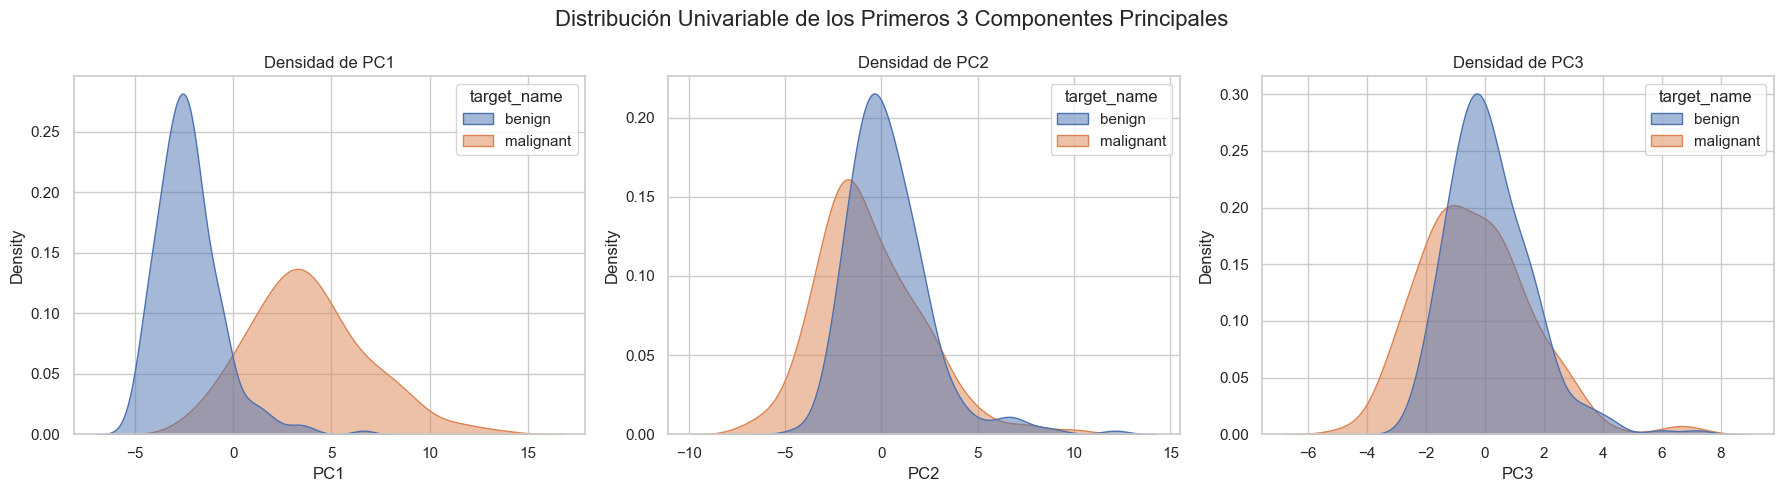

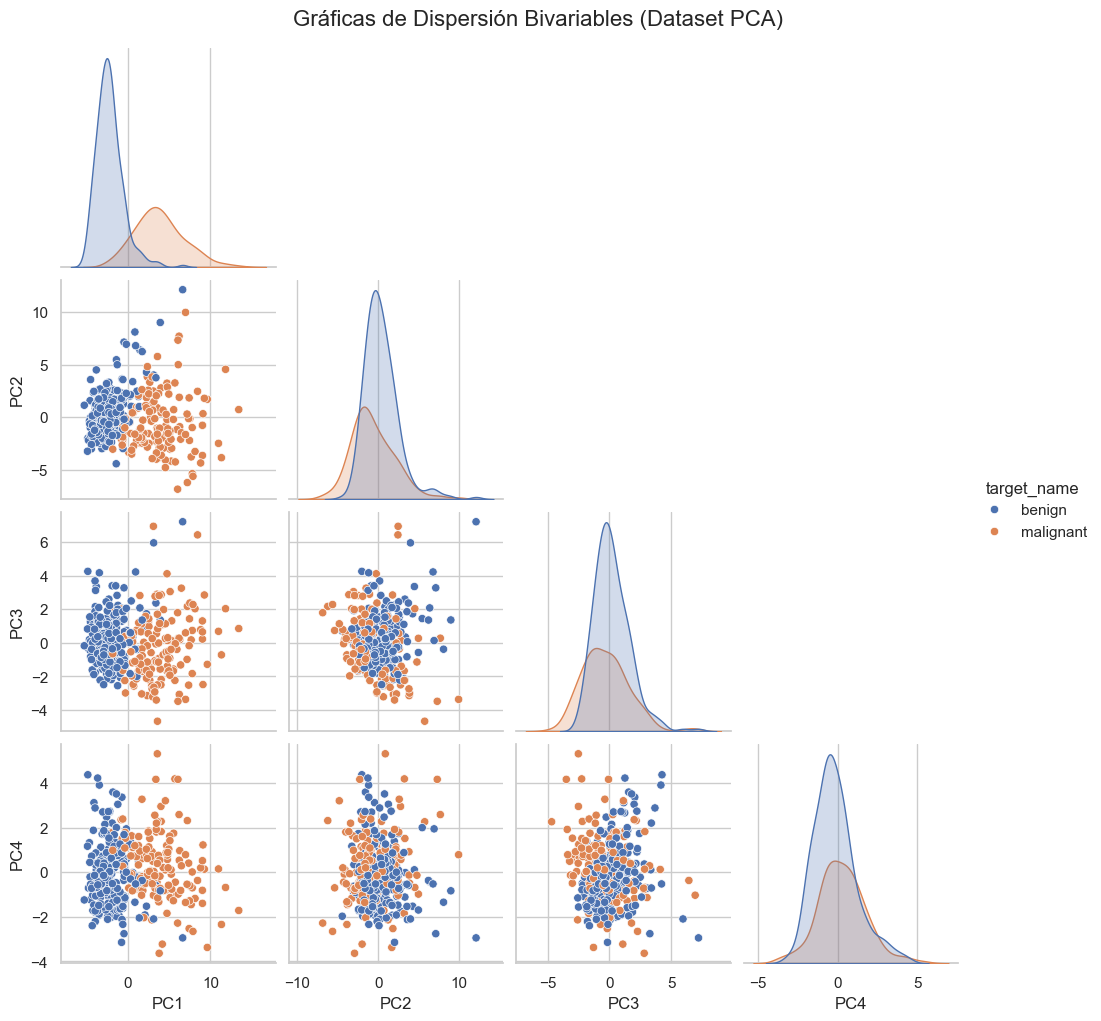

In [12]:
# Añadimos la etiqueta de clase al DataFrame de PCA para graficar
df_pca_plot = df_train_pca.copy()
df_pca_plot['target_name'] = y_train.map({0: 'malignant', 1: 'benign'}).values

# 1. Análisis Univariable: densidad de los primeros 3 componentes principales
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
for i in range(3):
    sns.kdeplot(data=df_pca_plot, x=f'PC{i+1}', hue="target_name", fill=True, common_norm=False, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Densidad de PC{i+1}")
plt.suptitle("Distribución Univariable de los Primeros 3 Componentes Principales", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Análisis Bivariable: pairplot de los primeros 4 componentes
sns.pairplot(df_pca_plot, vars=['PC1', 'PC2', 'PC3', 'PC4'], hue="target_name", diag_kind="kde", corner=True)
plt.suptitle("Gráficas de Dispersión Bivariables (Dataset PCA)", y=1.02, fontsize=16)
plt.show()

Compara estas gráficas con las de las secciones 3 y 4. Nota cómo PC1 por sí solo logra una separación de clases notable, comparable o incluso superior a la de cualquier variable original individual. Esto tiene sentido: PC1 es la dirección de máxima varianza, y en un problema de clasificación la varianza frecuentemente está asociada con la diferencia entre clases. En las gráficas de dispersión, la combinación PC1 vs PC2 suele mostrar la mejor separación visual.

## 12. Interpretación de PCA: Cargas (Loadings)

Las cargas (loadings) son los coeficientes que definen cada componente principal como combinación lineal de las variables originales. Recordemos que el primer componente principal se define como $Z_1 = \phi_{11}X_1 + \phi_{21}X_2 + \cdots + \phi_{p1}X_p$, donde los valores del vector de carga $\phi_1 = (\phi_{11}, \phi_{21}, \ldots, \phi_{p1})^T$ indican cuánto contribuye cada variable original (estandarizada) a ese componente, revelando cuáles son más influyentes en la variabilidad capturada.

Un valor de carga alto en valor absoluto indica que esa variable tiene un gran peso en la formación del componente. El signo indica la dirección: variables con el mismo signo se mueven juntas, mientras que signos opuestos indican relaciones inversas.

En scikit-learn, los loadings se encuentran en `pca.components_`, donde cada fila es un componente y cada columna una variable original. Transponemos la matriz para que las variables originales queden como filas y podamos ordenarlas por su aporte a cada componente.

In [13]:
# pca.components_ tiene shape (n_componentes, n_variables_originales)
# Lo transponemos para tener variables como filas y componentes como columnas
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=cancer_data.feature_names
)

# Analizamos las variables con mayor aporte a PC1 y PC2
for pc in ['PC1', 'PC2']:
    print(f"\n--- Variables con mayor aporte en {pc} (en valor absoluto) ---")
    pc_loadings = loadings[pc].to_frame()
    # Valor absoluto para ordenar por importancia sin importar el signo
    pc_loadings['Abs_Loading'] = pc_loadings[pc].abs()
    pc_sorted = pc_loadings.sort_values(by='Abs_Loading', ascending=False)
    
    # Top 10 variables
    display(pc_sorted[[pc, 'Abs_Loading']].head(10).round(4))

print("\nInterpretación:")
print("Variables con cargas altas (positivas o negativas) son las que más influyen en la varianza capturada por ese componente.")


--- Variables con mayor aporte en PC1 (en valor absoluto) ---


,PC1,Abs_Loading
mean concave points,0.2591,0.2591
mean concavity,0.2536,0.2536
worst concave points,0.2501,0.2501
mean compactness,0.2392,0.2392
worst perimeter,0.2351,0.2351
worst concavity,0.2304,0.2304
worst radius,0.2267,0.2267
mean perimeter,0.2253,0.2253
worst area,0.2233,0.2233
mean area,0.2196,0.2196



--- Variables con mayor aporte en PC2 (en valor absoluto) ---


,PC2,Abs_Loading
mean fractal dimension,0.3613,0.3613
fractal dimension error,0.2794,0.2794
worst fractal dimension,0.2689,0.2689
compactness error,0.2356,0.2356
mean radius,-0.2322,0.2322
mean area,-0.2265,0.2265
worst radius,-0.2195,0.2195
worst area,-0.2164,0.2164
mean perimeter,-0.2134,0.2134
smoothness error,0.2093,0.2093



Interpretación:
Variables con cargas altas (positivas o negativas) son las que más influyen en la varianza capturada por ese componente.


En los resultados podemos ver que las variables con mayor aporte en **PC1** son `mean concave points`, `mean concavity`, `worst concave points` y `mean compactness`. Todas están relacionadas con la **forma e irregularidad** del núcleo celular, no tanto con el tamaño. Esto nos indica que PC1 captura principalmente información sobre qué tan irregular o cóncavo es el contorno del tumor, lo cual tiene sentido clínico: los tumores malignos tienden a tener bordes más irregulares y mayor concavidad que los benignos.

En **PC2**, en cambio, dominan variables como `mean fractal dimension`, `fractal dimension error` y `worst fractal dimension`, junto con algunas variables de tamaño (`mean radius`, `mean area`) pero con signo negativo. Esto sugiere que PC2 captura un contraste entre la complejidad del contorno (dimensión fractal) y el tamaño del tumor.

De esta manera, aunque los componentes principales son construcciones matemáticas abstractas, las cargas nos permiten "traducirlos" de vuelta al lenguaje de las variables originales y darles una interpretación con significado.

## 13. Comparación de Heatmaps de los datasets

Ahora compararemos visualmente las matrices de datos del dataset original estandarizado y del dataset transformado por PCA. En estos heatmaps (generados con `sns.heatmap()`), el eje horizontal representa las variables (o componentes) y el eje vertical las observaciones.

El objetivo es observar cómo cambia la estructura de los datos después de la transformación PCA.

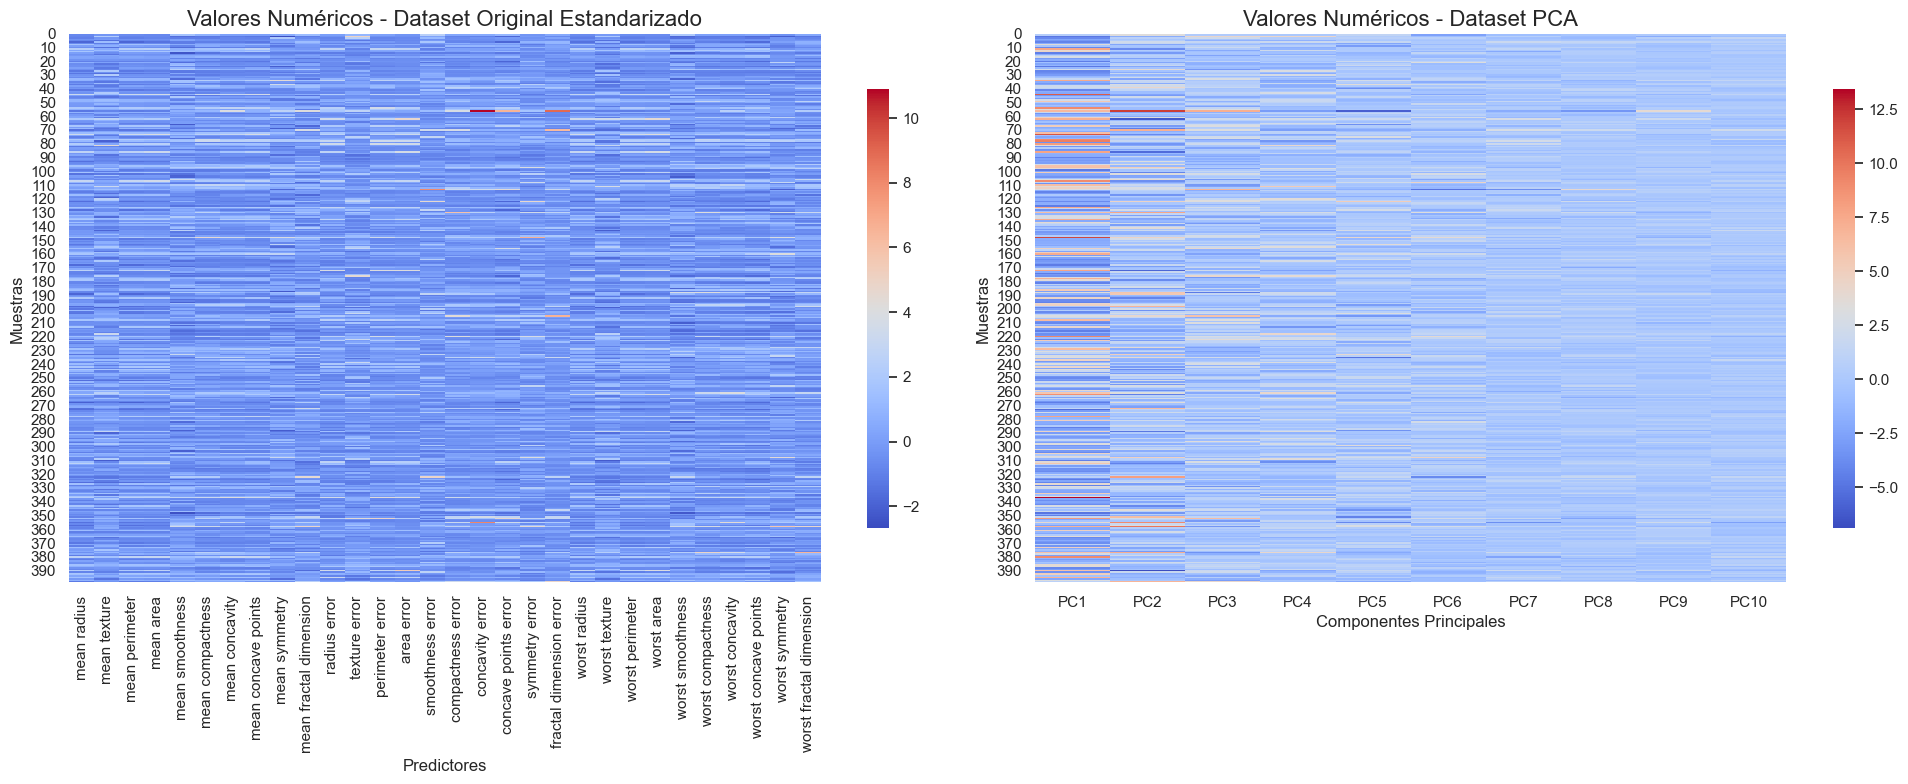

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap del dataset original estandarizado
sns.heatmap(df_train_scaled_heatmap, cmap='coolwarm', ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Valores Numéricos - Dataset Original Estandarizado', fontsize=16)
axes[0].set_xlabel('Predictores')
axes[0].set_ylabel('Muestras')

# Heatmap del dataset transformado con PCA
sns.heatmap(df_train_pca, cmap='coolwarm', ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Valores Numéricos - Dataset PCA', fontsize=16)
axes[1].set_xlabel('Componentes Principales')
axes[1].set_ylabel('Muestras')

plt.tight_layout()
plt.show()

En el heatmap del dataset original se pueden ver patrones de color similares entre varias columnas, lo que refleja la correlación entre variables (por ejemplo, radio, perímetro y área suelen moverse juntos y por eso tienen colores similares fila a fila). En el heatmap de PCA, cada columna captura información distinta e independiente, y las primeras columnas concentran la mayor variabilidad (colores más intensos), mientras que las últimas tienen valores más uniformes y cercanos a cero.

## 14. Mapas de correlación (Heatmaps)

Una de las propiedades más importantes de PCA es que los componentes principales son ortogonales, es decir, no están correlacionados entre sí. Verifiquemos esto visualmente comparando los mapas de correlación (calculados con `.corr()`) del dataset original contra el transformado.

Usamos `vmin=-1, vmax=1` para que ambos heatmaps compartan la misma escala de color y la comparación sea justa.

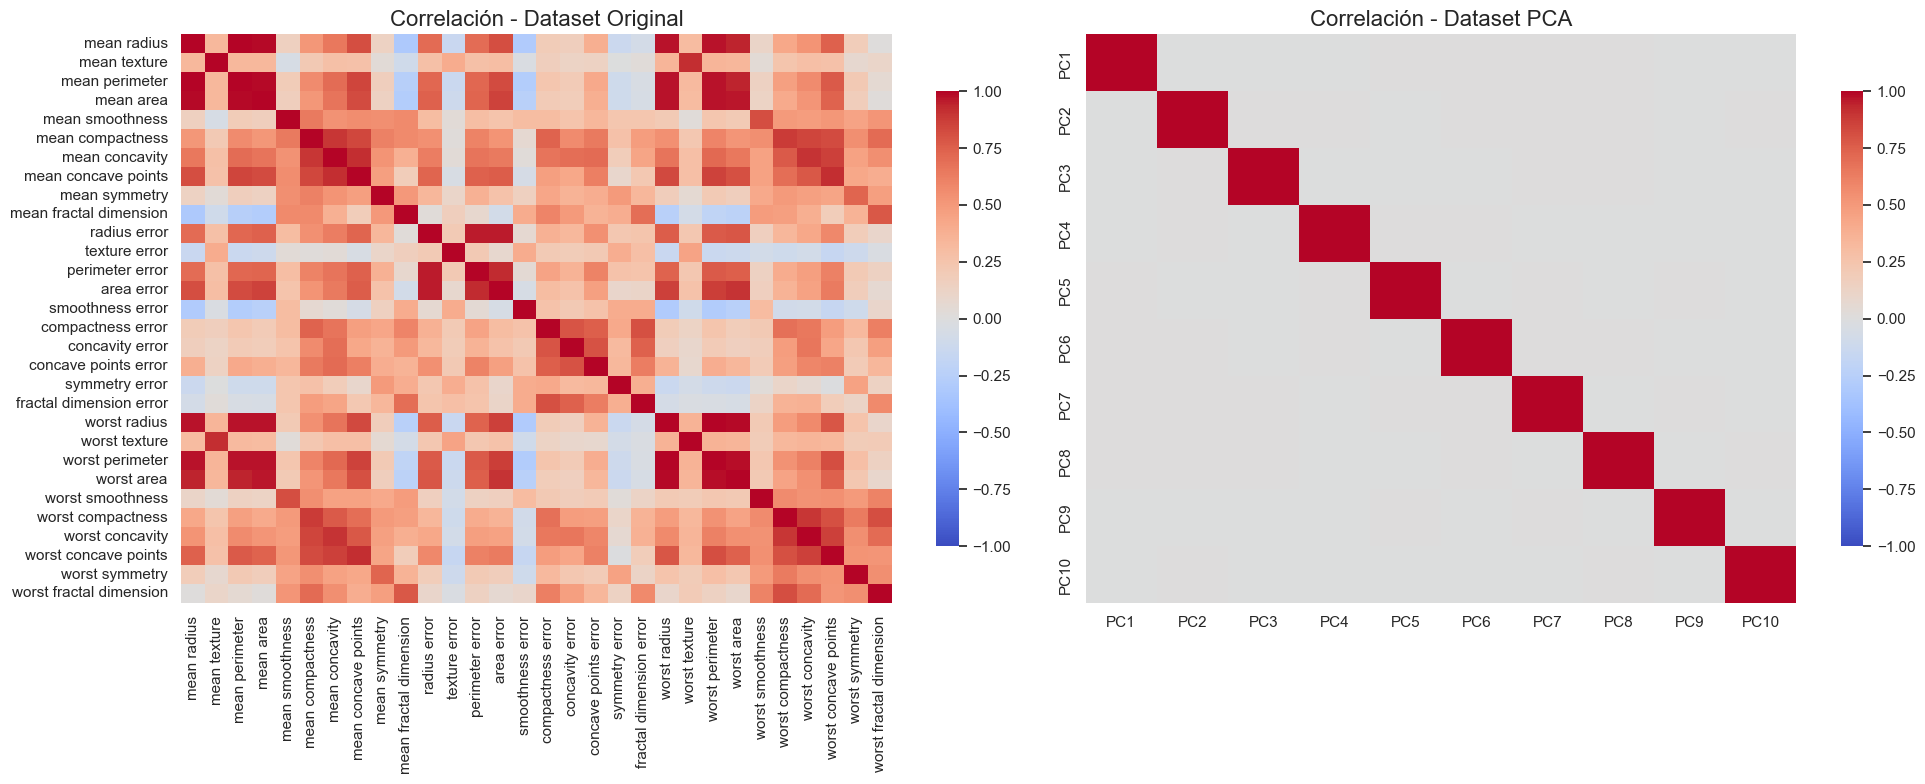

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Correlación del dataset original
sns.heatmap(df_train_scaled_heatmap.corr(), cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
axes[0].set_title('Correlación - Dataset Original', fontsize=16)

# Correlación del dataset PCA
sns.heatmap(df_train_pca.corr(), cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
axes[1].set_title('Correlación - Dataset PCA', fontsize=16)

plt.tight_layout()
plt.show()

El contraste es muy claro. En el dataset original se observan bloques de colores intensos fuera de la diagonal, indicando alta multicolinealidad (muchas variables miden esencialmente lo mismo, es decir, hay información redundante). En el dataset PCA, la matriz de correlación es prácticamente una matriz identidad: solo la diagonal tiene valores de 1 y el resto es prácticamente 0.

Esto confirma que PCA eliminó exitosamente la correlación entre variables. Esta decorrelación es una de las ventajas clave de PCA como preprocesamiento, ya que muchos modelos (incluida la regresión logística) se benefician de tener variables predictoras independientes.

## 15. Clasificación con el nuevo dataset (PCA)

Ahora entrenaremos un nuevo modelo de Regresión Logística, pero usando el dataset transformado por PCA en lugar de las 30 variables originales. Seguimos exactamente el mismo procedimiento: `GridSearchCV` con el mismo `param_grid`, optimizando F1-Score con 5 folds de validación cruzada. Esto nos permitirá hacer una comparación justa con el modelo original.

In [16]:
logreg_pca = LogisticRegression(solver='liblinear', random_state=42)

grid_search_pca = GridSearchCV(
    estimator=logreg_pca,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Entrenamos con los datos transformados por PCA
grid_search_pca.fit(X_train_pca, y_train)
best_logreg_pca = grid_search_pca.best_estimator_

# Predicciones sobre el test (transformado por PCA)
y_pred_pca = best_logreg_pca.predict(X_test_pca)
y_pred_proba_pca = best_logreg_pca.predict_proba(X_test_pca)[:, 1]

# Métricas
acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
auc_pca = roc_auc_score(y_test, y_pred_proba_pca)

print("Hiperparámetros (Modelo PCA):", grid_search_pca.best_params_)
print("\n--- Resultados Finales (Dataset PCA) ---")
print(f"Accuracy : {acc_pca:.4f}")
print(f"F1 Score : {f1_pca:.4f}")
print(f"ROC AUC  : {auc_pca:.4f}")

print("\n--- Reporte de Clasificación Detallado (PCA) ---")
print(classification_report(y_test, y_pred_pca, target_names=['Maligno', 'Benigno']))

Hiperparámetros (Modelo PCA): {'C': 0.1, 'class_weight': None, 'penalty': 'l2'}

--- Resultados Finales (Dataset PCA) ---
Accuracy : 0.9825
F1 Score : 0.9860
ROC AUC  : 0.9968

--- Reporte de Clasificación Detallado (PCA) ---
              precision    recall  f1-score   support

     Maligno       0.98      0.97      0.98        64
     Benigno       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



## 16. Comparativa de modelos con diferentes umbrales de PCA

Para entender mejor el impacto de la cantidad de componentes en el rendimiento, entrenaremos modelos variando el umbral de varianza retenida: 60%, 70%, 80%, 90% y 95%. Usaremos los mismos hiperparámetros encontrados en la búsqueda del modelo original para que la comparación sea justa y las diferencias se deban exclusivamente a la cantidad de componentes.

Esto nos permitirá observar si existe un punto donde agregar más componentes ya no mejora significativamente las métricas.

Resultados de clasificación variando el número de componentes:


,Umbral Varianza,Num_Componentes,Accuracy,F1 Score,ROC AUC
0,60%,2,0.9532,0.9626,0.9923
1,70%,3,0.9123,0.9296,0.9882
2,80%,4,0.9591,0.9680,0.9958
3,90%,7,0.9591,0.9668,0.9959
4,95%,10,0.9708,0.9763,0.9980


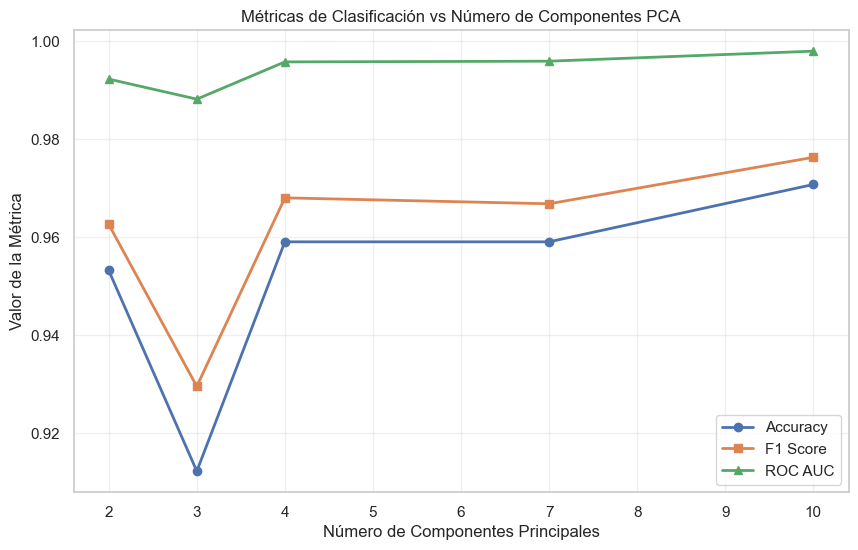

In [17]:
results_list = []
thresholds = [0.6, 0.7, 0.8, 0.9, 0.95]

# Usamos los mejores hiperparámetros del modelo original para comparación justa
best_params = grid_search.best_params_

for t in thresholds:
    # 1. Aplicar PCA con el umbral actual
    pca_t = PCA(n_components=t, random_state=42)
    X_train_t = pca_t.fit_transform(X_train_scaled)
    X_test_t = pca_t.transform(X_test_scaled)
    
    # 2. Entrenar modelo con los mismos hiperparámetros
    model_t = LogisticRegression(solver='liblinear', random_state=42, **best_params)
    model_t.fit(X_train_t, y_train)
    
    # 3. Evaluar en test
    y_pred_t = model_t.predict(X_test_t)
    y_pred_proba_t = model_t.predict_proba(X_test_t)[:, 1]
    
    acc_t = accuracy_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    auc_t = roc_auc_score(y_test, y_pred_proba_t)
    
    results_list.append({
        'Umbral Varianza': f'{int(t*100)}%',
        'Num_Componentes': pca_t.n_components_,
        'Accuracy': acc_t,
        'F1 Score': f1_t,
        'ROC AUC': auc_t
    })

df_comparativa_pca = pd.DataFrame(results_list)

print("Resultados de clasificación variando el número de componentes:")
display(df_comparativa_pca.round(4))

# Gráfica de métricas vs número de componentes
plt.figure(figsize=(10, 6))
plt.plot(df_comparativa_pca['Num_Componentes'], df_comparativa_pca['Accuracy'], marker='o', label='Accuracy', lw=2)
plt.plot(df_comparativa_pca['Num_Componentes'], df_comparativa_pca['F1 Score'], marker='s', label='F1 Score', lw=2)
plt.plot(df_comparativa_pca['Num_Componentes'], df_comparativa_pca['ROC AUC'], marker='^', label='ROC AUC', lw=2)

plt.title('Métricas de Clasificación vs Número de Componentes PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Valor de la Métrica')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La gráfica muestra un comportamiento interesante. Con solo 2 componentes (60% de varianza) ya se obtienen métricas bastante aceptables. Sin embargo, al pasar a 3 componentes (70%) se observa una caída en Accuracy y F1 Score, lo cual puede parecer contraintuitivo: más información no siempre mejora el modelo, ya que ese tercer componente podría estar introduciendo ruido o una dirección de varianza que no es útil para la clasificación.

A partir de 4 componentes (80% de varianza) las métricas se recuperan y se estabilizan en valores altos, muy cercanos a los del modelo original con 30 variables. Esto nos indica que con aproximadamente 4 componentes ya capturamos la información necesaria para clasificar correctamente, y agregar más componentes (7 o 10) aporta mejoras marginales. De las 30 variables originales, la mayor parte eran redundantes.

## 17. Comparativa final: Original vs PCA

Finalmente, veamos lado a lado las métricas del modelo entrenado con las 30 variables originales contra el modelo entrenado con los componentes principales al 95% de varianza.

In [18]:
resultados = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1 Score', 'ROC AUC'],
    'Original (30 vars)': [acc, f1, auc],
    'PCA ({} vars)'.format(pca.n_components_): [acc_pca, f1_pca, auc_pca]
})

resultados.set_index('Métrica', inplace=True)
print("Comparativa Final de Modelos:")
display(resultados.round(4))

Comparativa Final de Modelos:


,Original (30 vars),PCA (10 vars)
Métrica,,
Accuracy,0.9883,0.9825
F1 Score,0.9907,0.9860
ROC AUC,0.9981,0.9968


Con esta tabla podemos ver que el modelo PCA (10 variables) obtuvo métricas prácticamente idénticas al modelo original (30 variables). De hecho, en ROC AUC el modelo PCA fue ligeramente superior. Esto confirma que PCA funcionó bien como paso de preprocesamiento: logramos reducir las variables a un tercio sin perder capacidad de clasificación.

### ¿Qué aprendimos en este tutorial?

A lo largo del notebook recorrimos el proceso completo de aplicar PCA como etapa de preprocesamiento para clasificación. Algunos puntos clave que vale la pena recordar:

- **La estandarización es obligatoria antes de PCA.** Si no la hacemos, las variables con mayor magnitud dominarán los componentes principales simplemente por su escala, no por su importancia real.
- **No todos los componentes son igual de útiles.** El análisis de varianza explicada nos mostró que los primeros componentes concentran la gran mayoría de la información, y los últimos aportan cantidades marginales. Encontrar el "codo" o definir un umbral de varianza nos permite decidir cuántos conservar.
- **Más componentes no siempre es mejor.** Vimos en la comparativa por umbrales que con 3 componentes el rendimiento cayó, pero con 4 ya se recuperó y se estabilizó. Esto refuerza la importancia de probar diferentes configuraciones en lugar de asumir que más información es siempre mejor.
- **PCA elimina la multicolinealidad.** Los mapas de correlación mostraron cómo el dataset original tenía muchas variables redundantes, mientras que los componentes principales son completamente independientes entre sí.
- **Las cargas nos permiten interpretar los componentes.** Aunque PC1 y PC2 son combinaciones lineales abstractas, pudimos identificar que PC1 captura información sobre la forma e irregularidad del tumor, y PC2 sobre la complejidad del contorno vs el tamaño.

Finalmente, vale la pena mencionar que las métricas altas en ambos modelos (~0.97-0.99) se deben en buena medida a que el dataset Breast Cancer Wisconsin es relativamente limpio y las clases son razonablemente separables. En datasets más complejos o ruidosos, las métricas serían más bajas y la ventaja de PCA en términos de reducir el sobreajuste podría ser aún más evidente.